##Importing dataset

In [ ]:
!pip install ucimlrepo

from ucimlrepo import fetch_ucirepo
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# fetch dataset
wine = fetch_ucirepo(id=109)

# data (as pandas dataframes)
X = wine.data.features
y = wine.data.targets

# metadata
print(wine.metadata)

# variable information
print(wine.variables)


{'uci_id': 109, 'name': 'Wine', 'repository_url': 'https://archive.ics.uci.edu/dataset/109/wine', 'data_url': 'https://archive.ics.uci.edu/static/public/109/data.csv', 'abstract': 'Using chemical analysis to determine the origin of wines', 'area': 'Physics and Chemistry', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 178, 'num_features': 13, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1992, 'last_updated': 'Mon Aug 28 2023', 'dataset_doi': '10.24432/C5PC7J', 'creators': ['Stefan Aeberhard', 'M. Forina'], 'intro_paper': {'ID': 246, 'type': 'NATIVE', 'title': 'Comparative analysis of statistical pattern recognition methods in high dimensional settings', 'authors': 'S. Aeberhard, D. Coomans, O. Vel', 'venue': 'Pattern Recognition', 'year': 1994, 'journal': None, 'DOI': '10.1016/0031-3203(94)90145-7', 'URL': 'https:

In [ ]:
X

,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [ ]:
y

,class
0,1
1,1
2,1
3,1
4,1
...,...
173,3
174,3
175,3
176,3


##Class distribution

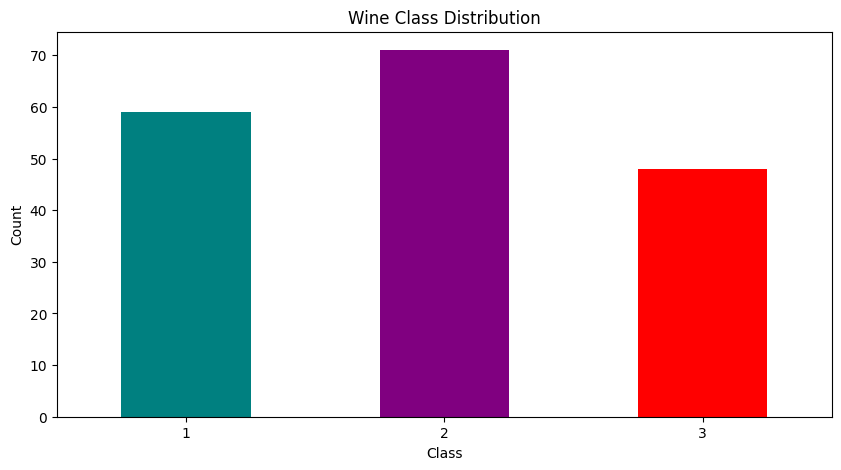

In [ ]:
y_counts = y["class"].value_counts().sort_index()
y_counts.plot(kind = 'bar',color = ["Teal","Purple","Red"],figsize = (10,5))


plt.title("Wine Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

#Baseline MLP classifier with:

**Optimizer:** `Adam` with
`learning rate` starting at 0.01 and deacreasing by half every 20 epochs

Loss function :`sparse_categorical_crossentropy`

Epochs: `50`

Batch size: `32`

Activation function: `softmax`

`l2 regularization (0.001)` ; `Dropout(0.2)`

`Dense(16)` ; `Dense(8)` ; `Dense(4)`

5 folds for cross validation



In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import LearningRateScheduler
from ucimlrepo import fetch_ucirepo
import numpy as np
from sklearn.metrics import accuracy_score
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers


early_stopper = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Fetch dataset
wine = fetch_ucirepo(id=109)

X = wine.data.features.values
y = wine.data.targets.values.flatten()

y = y.astype(int).flatten() - 1


num_classes = len(np.unique(y))

def lr_scheduler(epoch, lr):
    if epoch % 20 == 0 and epoch != 0:
        lr = lr * 0.5
    return lr

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store metrics across folds
fold_train_loss = []
fold_val_loss = []
fold_train_acc = []
fold_val_acc = []
fold_acc_scores = []

# Loop over folds
for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # Scale features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    # Define classification model
    model = Sequential([
      Dense(16, input_dim=X_train.shape[1], activation='relu', kernel_regularizer=regularizers.l2(0.001)),
      Dropout(0.2),
      Dense(8, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
      Dropout(0.2),
      Dense(4, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
      Dropout(0.2),
      Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer=Adam(learning_rate=0.01),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    # Train
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=32,
        verbose=0,
        callbacks=[LearningRateScheduler(lr_scheduler)]
    )

    # Store full training history
    fold_train_loss.append(history.history['loss'])
    fold_val_loss.append(history.history['val_loss'])
    fold_train_acc.append(history.history['accuracy'])
    fold_val_acc.append(history.history['val_accuracy'])

    # Evaluate
    y_pred = model.predict(X_val)
    y_pred_classes = np.argmax(y_pred, axis=1)
    acc = accuracy_score(y_val, y_pred_classes)
    fold_acc_scores.append(acc)

    print(f"Fold {fold}: Accuracy = {acc:.4f}")

print("\nAverage Accuracy across folds:", np.mean(fold_acc_scores))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
Fold 1: Accuracy = 1.0000


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step
Fold 2: Accuracy = 0.9444


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
Fold 3: Accuracy = 1.0000


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
Fold 4: Accuracy = 0.9429


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 320ms/step
Fold 5: Accuracy = 1.0000

Average Accuracy across folds: 0.9774603174603176


##Evaluation

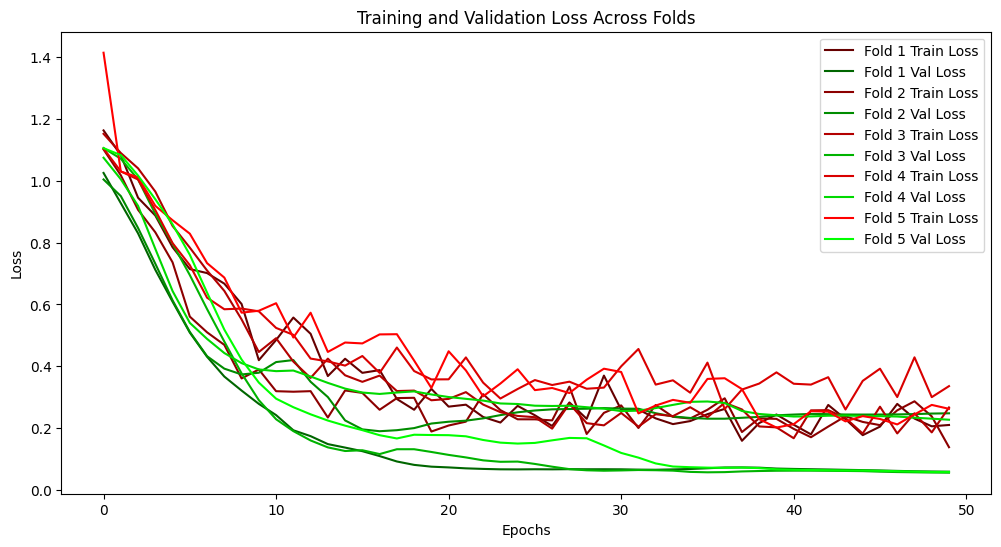

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

num_folds = len(fold_train_loss)

# Create a figure
plt.figure(figsize=(12, 6))

# Generate shades
reds = np.linspace(0.4, 1.0, num_folds)
greens = np.linspace(0.4, 1.0, num_folds)

for i in range(num_folds):
    plt.plot(fold_train_loss[i], color=(reds[i], 0, 0), label=f'Fold {i+1} Train Loss')
    plt.plot(fold_val_loss[i], color=(0, greens[i], 0), label=f'Fold {i+1} Val Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Across Folds')
plt.legend()
plt.show()


##Train and validation loss

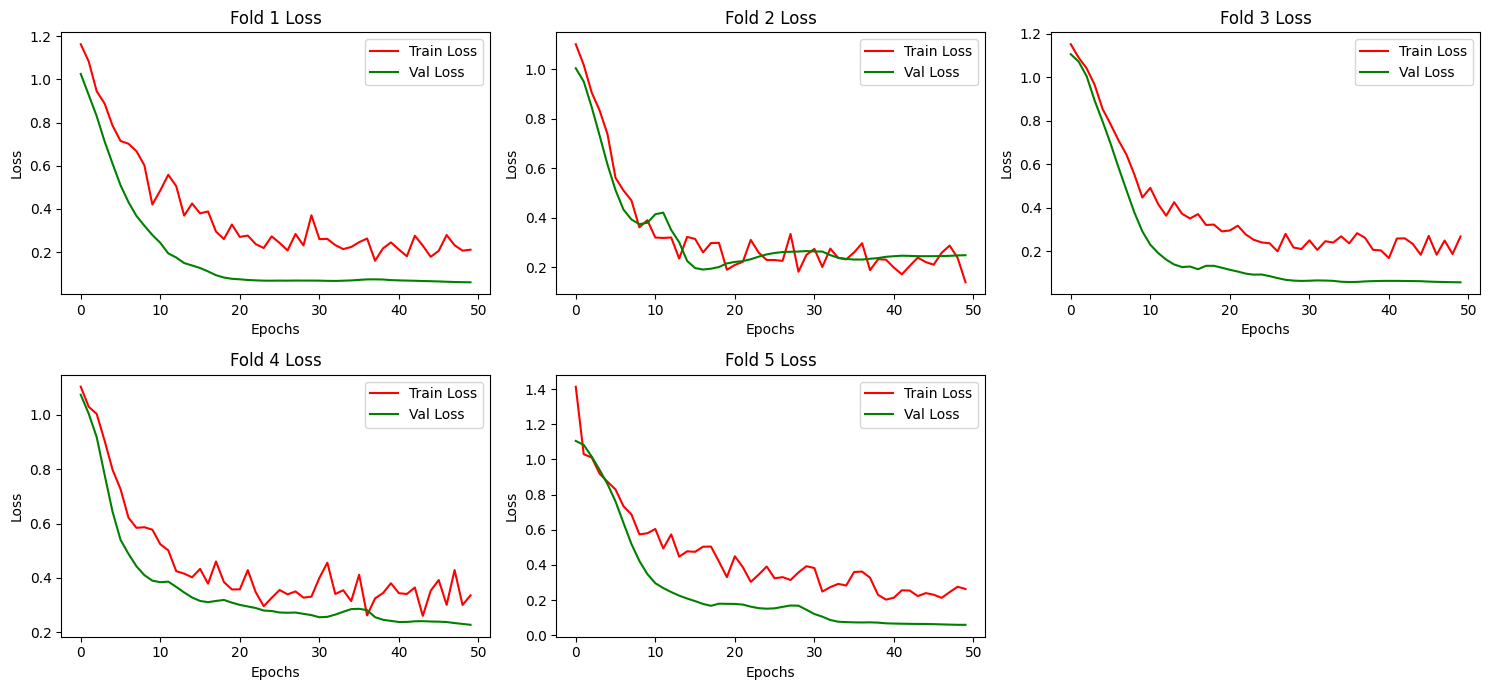

In [ ]:
import matplotlib.pyplot as plt

num_folds = len(fold_train_loss)

plt.figure(figsize=(15, 7))

for i in range(num_folds):
    plt.subplot(2, 3, i+1)
    plt.plot(fold_train_loss[i], color='red', label='Train Loss')
    plt.plot(fold_val_loss[i], color='green', label='Val Loss')
    plt.title(f"Fold {i+1} Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

plt.tight_layout()
plt.show()


##Accuracy score

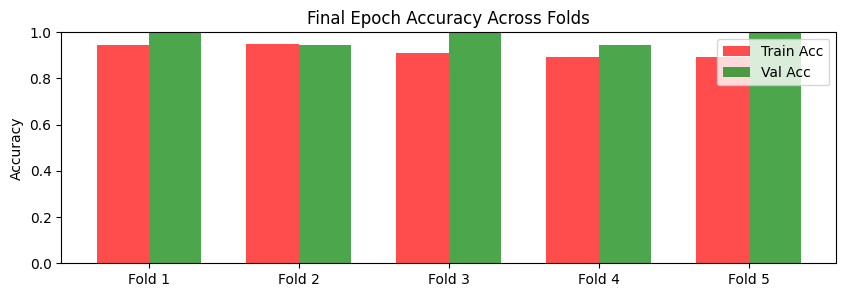

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

num_folds = len(fold_train_acc)

train_final_acc = [fold_train_acc[i][-1] for i in range(num_folds)]
val_final_acc = [fold_val_acc[i][-1] for i in range(num_folds)]

x = np.arange(num_folds)
width = 0.35

plt.figure(figsize=(10, 3))
plt.bar(x - width/2, train_final_acc, width, color='red', alpha=0.7, label='Train Acc')
plt.bar(x + width/2, val_final_acc, width, color='green', alpha=0.7, label='Val Acc')

plt.xticks(x, [f'Fold {i+1}' for i in range(num_folds)])
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.title('Final Epoch Accuracy Across Folds')
plt.legend()
plt.show()



#Baseline MLP classifier with:

**Optimizer:** `SGD` with
`learning rate` starting at 0.01 and deacreasing by half every 20 epochs

Loss function :`sparse_categorical_crossentropy`

Epochs: `100`

Batch size: `32`

Activation function: `softmax`

`Dropout(0.1)`

`Dense(16)` ; `Dense(8)` ; `Dense(4)`

5 folds for cross validation



In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import LearningRateScheduler
from ucimlrepo import fetch_ucirepo
import numpy as np
from sklearn.metrics import accuracy_score
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers
import matplotlib.pyplot as plt

early_stopper = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Fetch dataset
wine = fetch_ucirepo(id=109)

X = wine.data.features.values
y = wine.data.targets.values.flatten()

y = y.astype(int).flatten() - 1


num_classes = len(np.unique(y))

def lr_scheduler(epoch, lr):
    if epoch % 20 == 0 and epoch != 0:
        lr = lr * 0.5
    return lr

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store metrics across folds
fold_train_loss = []
fold_val_loss = []
fold_train_acc = []
fold_val_acc = []
fold_acc_scores = []

# Loop over folds
for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # Scale features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    # Define classification model
    model = Sequential([
      Dense(16, input_dim=X_train.shape[1], activation='relu'),
      Dropout(0.10),
      Dense(8, activation='relu'),
      Dropout(0.10),
      Dense(4, activation='relu'),
      Dropout(0.10),
      Dense(num_classes, activation='softmax')
    ])


    sgd_optimizer = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)

    model.compile(optimizer=sgd_optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    # Train
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=32,
        verbose=0,
        callbacks=[LearningRateScheduler(lr_scheduler), early_stopper]
    )

    # Store full training history
    fold_train_loss.append(history.history['loss'])
    fold_val_loss.append(history.history['val_loss'])
    fold_train_acc.append(history.history['accuracy'])
    fold_val_acc.append(history.history['val_accuracy'])

    # Evaluate
    y_pred = model.predict(X_val)
    y_pred_classes = np.argmax(y_pred, axis=1)
    acc = accuracy_score(y_val, y_pred_classes)
    fold_acc_scores.append(acc)

    print(f"Fold {fold}: Accuracy = {acc:.4f}")

print("\nAverage Accuracy across folds:", np.mean(fold_acc_scores))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
Fold 1: Accuracy = 1.0000


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
Fold 2: Accuracy = 0.6667


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
Fold 3: Accuracy = 0.9444


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
Fold 4: Accuracy = 0.9429


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
Fold 5: Accuracy = 1.0000

Average Accuracy across folds: 0.9107936507936507


##Evaluation

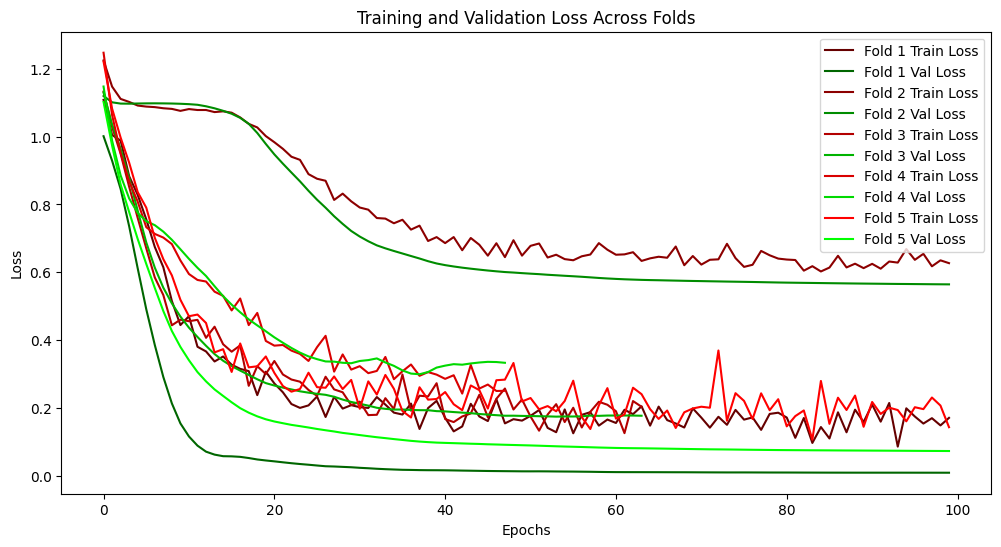

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

num_folds = len(fold_train_loss)

# Create a figure
plt.figure(figsize=(12, 6))

# Generate shades
reds = np.linspace(0.4, 1.0, num_folds)
greens = np.linspace(0.4, 1.0, num_folds)

for i in range(num_folds):
    plt.plot(fold_train_loss[i], color=(reds[i], 0, 0), label=f'Fold {i+1} Train Loss')
    plt.plot(fold_val_loss[i], color=(0, greens[i], 0), label=f'Fold {i+1} Val Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Across Folds')
plt.legend()
plt.show()


##Train and validation loss

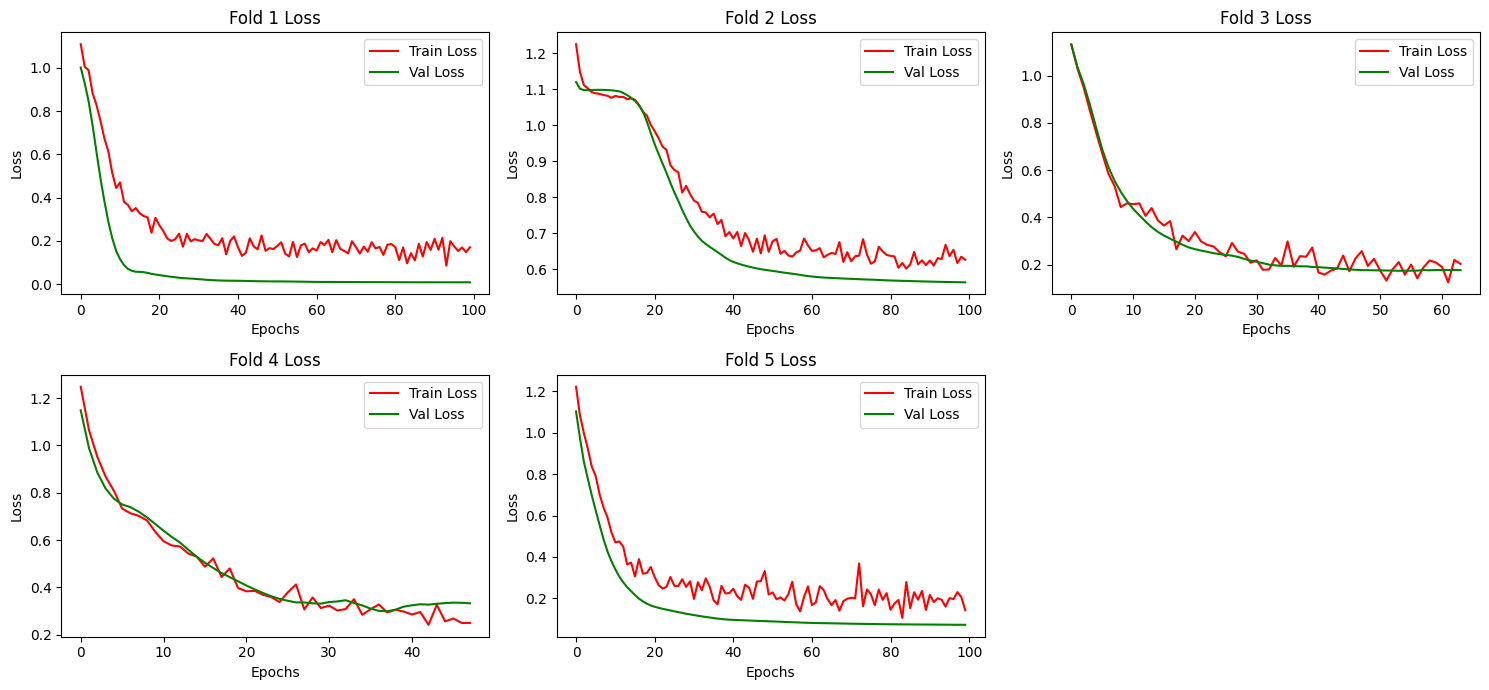

In [ ]:
import matplotlib.pyplot as plt

num_folds = len(fold_train_loss)

plt.figure(figsize=(15, 7))

for i in range(num_folds):
    plt.subplot(2, 3, i+1)
    plt.plot(fold_train_loss[i], color='red', label='Train Loss')
    plt.plot(fold_val_loss[i], color='green', label='Val Loss')
    plt.title(f"Fold {i+1} Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

plt.tight_layout()
plt.show()


#Experimenting with different learning rates
##Baseline MLP classifier with:

**Optimizer:** `SGD` with
`learning rate` starting at 0.01 and deacreasing by 20% every 20 epochs

Loss function :`sparse_categorical_crossentropy`

Epochs: `100`

Batch size: `32`

Activation function: `softmax`

`Dropout(0.1)`

`Dense(16)` ; `Dense(8)` ; `Dense(4)`

5 folds for cross validation



In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import LearningRateScheduler
from ucimlrepo import fetch_ucirepo
import numpy as np
from sklearn.metrics import accuracy_score
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers
import matplotlib.pyplot as plt # Added for plotting

early_stopper = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Fetch dataset
wine = fetch_ucirepo(id=109)

X = wine.data.features.values
y = wine.data.targets.values.flatten()

y = y.astype(int).flatten() - 1


num_classes = len(np.unique(y))

def lr_scheduler(epoch, lr):
    if epoch % 20 == 0 and epoch != 0:
        lr = lr * 0.8
    return lr

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store metrics across folds
fold_train_loss = []
fold_val_loss = []
fold_train_acc = []
fold_val_acc = []
fold_acc_scores = []

# Loop over folds
for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # Scale features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    # Define classification model
    model = Sequential([
      Dense(16, input_dim=X_train.shape[1], activation='relu'),
      Dropout(0.10),
      Dense(8, activation='relu'),
      Dropout(0.10),
      Dense(4, activation='relu'),
      Dropout(0.10),
      Dense(num_classes, activation='softmax')
    ])


    sgd_optimizer = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)

    model.compile(optimizer=sgd_optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    # Train
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=32,
        verbose=0,
        callbacks=[LearningRateScheduler(lr_scheduler), early_stopper]
    )

    # Store full training history
    fold_train_loss.append(history.history['loss'])
    fold_val_loss.append(history.history['val_loss'])
    fold_train_acc.append(history.history['accuracy'])
    fold_val_acc.append(history.history['val_accuracy'])

    # Evaluate
    y_pred = model.predict(X_val)
    y_pred_classes = np.argmax(y_pred, axis=1)
    acc = accuracy_score(y_val, y_pred_classes)
    fold_acc_scores.append(acc)

    print(f"Fold {fold}: Accuracy = {acc:.4f}")

print("\nAverage Accuracy across folds:", np.mean(fold_acc_scores))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
Fold 1: Accuracy = 1.0000


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
Fold 2: Accuracy = 0.9167


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
Fold 3: Accuracy = 0.9722


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
Fold 4: Accuracy = 0.9714


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
Fold 5: Accuracy = 1.0000

Average Accuracy across folds: 0.9720634920634922


##Evaluation

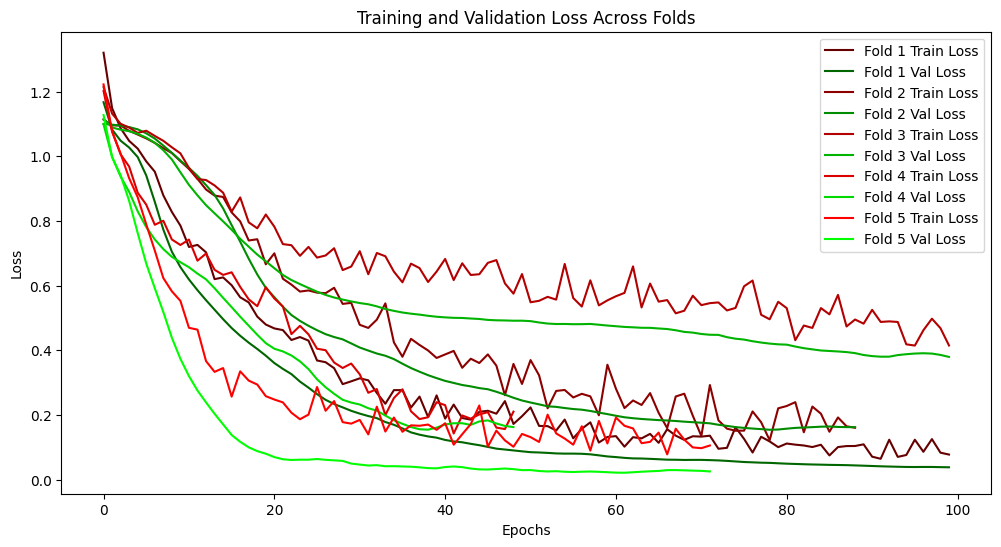

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

num_folds = len(fold_train_loss)

# Create a figure
plt.figure(figsize=(12, 6))

# Generate shades
reds = np.linspace(0.4, 1.0, num_folds)
greens = np.linspace(0.4, 1.0, num_folds)

for i in range(num_folds):
    plt.plot(fold_train_loss[i], color=(reds[i], 0, 0), label=f'Fold {i+1} Train Loss')
    plt.plot(fold_val_loss[i], color=(0, greens[i], 0), label=f'Fold {i+1} Val Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Across Folds')
plt.legend()
plt.show()


##Train and validation loss

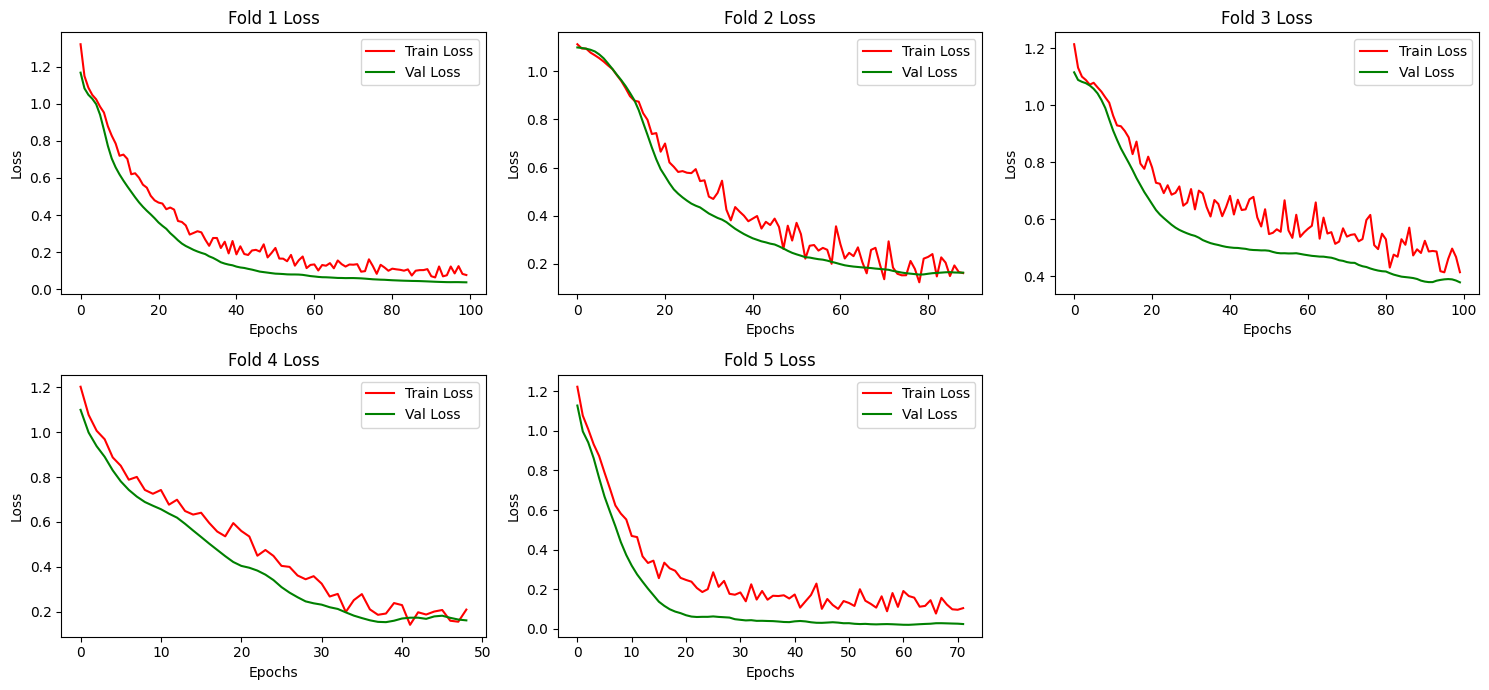

In [ ]:
import matplotlib.pyplot as plt

num_folds = len(fold_train_loss)

plt.figure(figsize=(15, 7))

for i in range(num_folds):
    plt.subplot(2, 3, i+1)
    plt.plot(fold_train_loss[i], color='red', label='Train Loss')
    plt.plot(fold_val_loss[i], color='green', label='Val Loss')
    plt.title(f"Fold {i+1} Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

plt.tight_layout()
plt.show()


#10% smaller learning rate for every 20 epochs no early stopping

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import LearningRateScheduler
from ucimlrepo import fetch_ucirepo
import numpy as np
from sklearn.metrics import accuracy_score
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers
import matplotlib.pyplot as plt # Added for plotting

early_stopper = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Fetch dataset
wine = fetch_ucirepo(id=109)

X = wine.data.features.values
y = wine.data.targets.values.flatten()

y = y.astype(int).flatten() - 1


num_classes = len(np.unique(y))

def lr_scheduler(epoch, lr):
    if epoch % 20 == 0 and epoch != 0:
        lr = lr * 0.9
    return lr

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store metrics across folds
fold_train_loss = []
fold_val_loss = []
fold_train_acc = []
fold_val_acc = []
fold_acc_scores = []

# Loop over folds
for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # Scale features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    # Define classification model
    model = Sequential([
      Dense(16, input_dim=X_train.shape[1], activation='relu'),
      Dropout(0.10),
      Dense(8, activation='relu'),
      Dropout(0.10),
      Dense(4, activation='relu'),
      Dropout(0.10),
      Dense(num_classes, activation='softmax')
    ])


    sgd_optimizer = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)

    model.compile(optimizer=sgd_optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    # Train
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=32,
        verbose=0,
        callbacks=[LearningRateScheduler(lr_scheduler)]
    )

    # Store full training history
    fold_train_loss.append(history.history['loss'])
    fold_val_loss.append(history.history['val_loss'])
    fold_train_acc.append(history.history['accuracy'])
    fold_val_acc.append(history.history['val_accuracy'])

    # Evaluate
    y_pred = model.predict(X_val)
    y_pred_classes = np.argmax(y_pred, axis=1)
    acc = accuracy_score(y_val, y_pred_classes)
    fold_acc_scores.append(acc)

    print(f"Fold {fold}: Accuracy = {acc:.4f}")

print("\nAverage Accuracy across folds:", np.mean(fold_acc_scores))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
Fold 1: Accuracy = 1.0000


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 309ms/step
Fold 2: Accuracy = 0.9444


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
Fold 3: Accuracy = 0.9722


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step
Fold 4: Accuracy = 0.9714


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
Fold 5: Accuracy = 1.0000

Average Accuracy across folds: 0.9776190476190475


##Evaluation

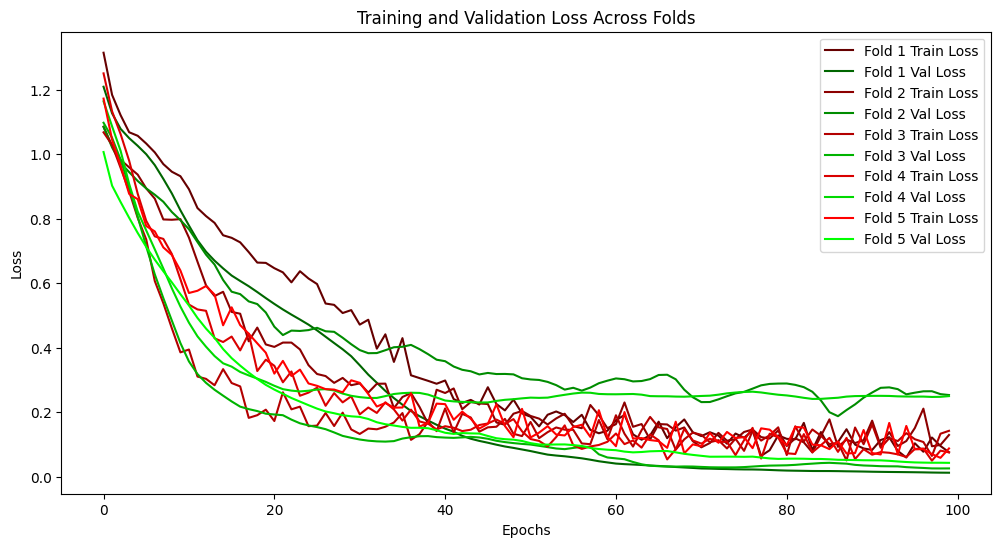

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

num_folds = len(fold_train_loss)

# Create a figure
plt.figure(figsize=(12, 6))

# Generate shades
reds = np.linspace(0.4, 1.0, num_folds)
greens = np.linspace(0.4, 1.0, num_folds)

for i in range(num_folds):
    plt.plot(fold_train_loss[i], color=(reds[i], 0, 0), label=f'Fold {i+1} Train Loss')
    plt.plot(fold_val_loss[i], color=(0, greens[i], 0), label=f'Fold {i+1} Val Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Across Folds')
plt.legend()
plt.show()


##Train and validation loss

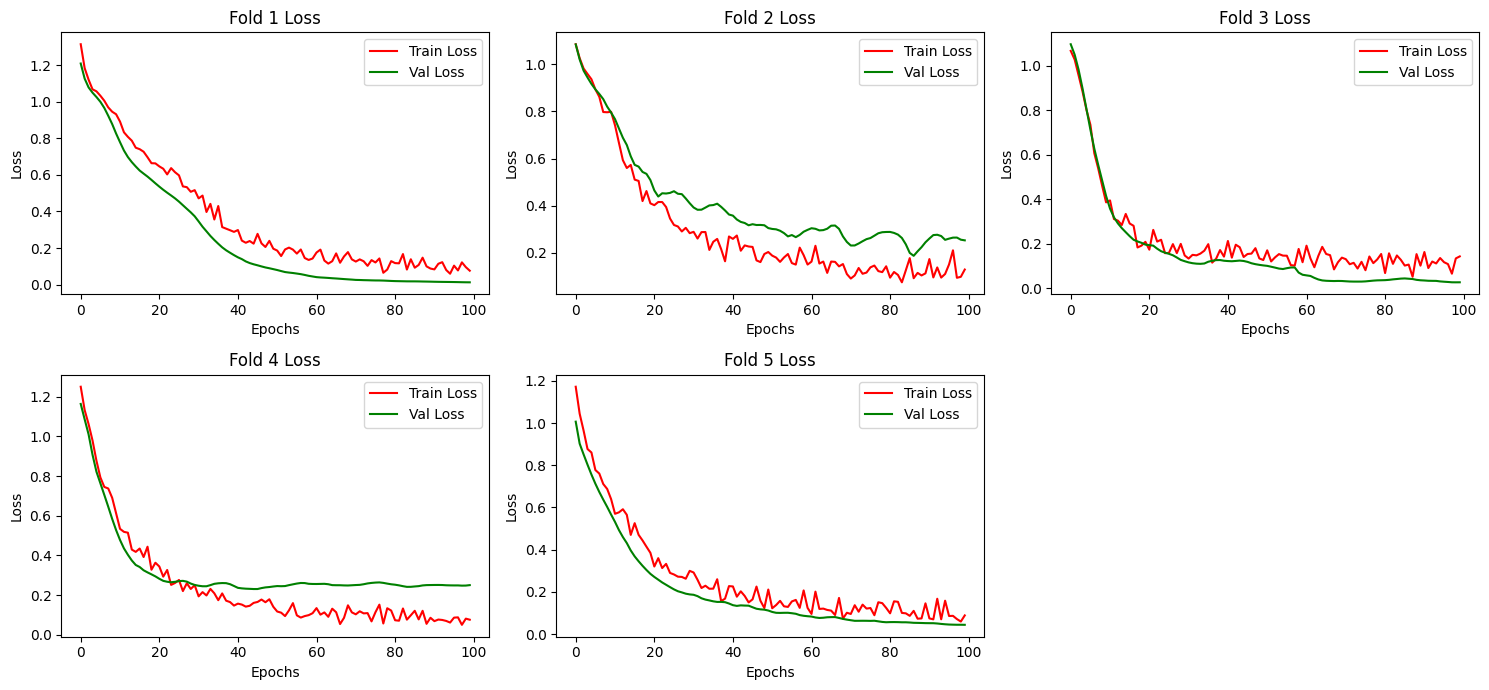

In [ ]:
import matplotlib.pyplot as plt

num_folds = len(fold_train_loss)

plt.figure(figsize=(15, 7))

for i in range(num_folds):
    plt.subplot(2, 3, i+1)
    plt.plot(fold_train_loss[i], color='red', label='Train Loss')
    plt.plot(fold_val_loss[i], color='green', label='Val Loss')
    plt.title(f"Fold {i+1} Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

plt.tight_layout()
plt.show()
